# Stopped fractional Kelly experiment

We simulate iid increments `X_i`, with `X_i = +u` with probability `p` and `X_i = -d` otherwise. For a fraction `f`, define `S_n = X_1 + ... + X_n` and stop at the first `N` such that `S_N <= -a/f` or `S_N >= b/f`. The objective below estimates `E[log(1 + f S_N)] / E[N]` and optimizes it over a grid of `f` values.

One-step benchmark: the process stops after one draw when both possible increments cross their barriers, meaning `f >= max(a/d, b/u)`. In particular, if `a = d` and `b = u`, this is one-step only for `f >= 1`. The exact one-step objective is `p log(1 + f u) + (1-p) log(1 - f d)`, whose unconstrained maximizer is the usual Kelly fraction.

In [2]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
import torch

torch.set_default_dtype(torch.float64)

In [15]:
# Experiment inputs: +u on a win, -d on a loss.
u = 0.10
d = 0.10
p = 0.60

# Stop when f*S_n leaves [-a, b]. Keep 0 < a < 1 for a positive stopped wealth floor.
a = 0.2
b = 2.0

# Monte Carlo and optimizer settings.
n_paths = 10_000
max_steps = 5_000
batch_size = 1_000
seed = 1234

# Because a downside step can overshoot the lower barrier, require f < (1-a)/d.
f_min = 0.02
f_max = 0.98 * (1.0 - a) / d
n_f = 80
classic_kelly = (p * u - (1.0 - p) * d) / (u * d)
f_grid = torch.linspace(f_min, f_max, n_f)

# Include the classical Kelly fraction exactly when it is in the admissible interval.
if f_min < classic_kelly < f_max:
    f_grid = torch.sort(torch.unique(torch.cat([f_grid, torch.tensor([classic_kelly])]))).values

In [16]:
def estimate_stopped_growth(
    u,
    d,
    p,
    a,
    b,
    f_values,
    *,
    n_paths=10_000,
    max_steps=5_000,
    batch_size=1_000,
    seed=1234,
):
    """Monte Carlo estimate of E[log(1 + f S_N)] / E[N] for many f values."""
    if not (u > 0 and d > 0):
        raise ValueError("Use positive u and d; increments are +u and -d.")
    if not (0 <= p <= 1):
        raise ValueError("p must be in [0, 1].")
    if not (0 < a < 1 and b > 0):
        raise ValueError("Need 0 < a < 1 and b > 0.")

    f_values = torch.as_tensor(f_values, dtype=torch.get_default_dtype()).reshape(-1)
    if bool(torch.any(f_values <= 0)):
        raise ValueError("f values must be positive.")

    f_safe_max = (1.0 - a) / d
    if bool(torch.any(f_values >= f_safe_max)):
        raise ValueError(
            f"Use f < (1-a)/d = {f_safe_max:.4g}; otherwise a downside overshoot can make log(1 + f*S_N) invalid."
        )

    lower = -a / f_values
    upper = b / f_values
    log_sum = torch.zeros_like(f_values)
    n_sum = torch.zeros_like(f_values)
    hit_count = torch.zeros(f_values.shape, dtype=torch.int64)

    generator = torch.Generator().manual_seed(seed)
    lower_col = lower[:, None]
    upper_col = upper[:, None]
    win_step = torch.as_tensor(u)
    loss_step = torch.as_tensor(-d)

    for start in range(0, n_paths, batch_size):
        m = min(batch_size, n_paths - start)
        S = torch.zeros(m)
        active = torch.ones((f_values.numel(), m), dtype=torch.bool)

        for n in range(1, max_steps + 1):
            wins = torch.rand(m, generator=generator) < p
            S += torch.where(wins, win_step, loss_step)

            crossed = active & ((S[None, :] <= lower_col) | (S[None, :] >= upper_col))
            if crossed.any():
                f_idx, path_idx = crossed.nonzero(as_tuple=True)
                log_values = torch.log1p(f_values[f_idx] * S[path_idx])
                log_sum.scatter_add_(0, f_idx, log_values)

                crossed_count = torch.bincount(f_idx, minlength=f_values.numel())
                n_sum += crossed_count.to(n_sum.dtype) * n
                hit_count += crossed_count
                active[f_idx, path_idx] = False

            if not active.any():
                break

    hit_rate = hit_count.to(torch.get_default_dtype()) / n_paths
    mean_log = log_sum / hit_count.clamp_min(1)
    mean_N = n_sum / hit_count.clamp_min(1)
    growth_rate = log_sum / n_sum.clamp_min(1.0)
    growth_rate = torch.where(hit_count > 0, growth_rate, torch.full_like(growth_rate, torch.nan))

    return {
        "f": f_values,
        "growth_rate": growth_rate,
        "mean_log": mean_log,
        "mean_N": mean_N,
        "hit_rate": hit_rate,
        "hits": hit_count,
    }


def one_step_growth(u, d, p, f_values):
    """Exact E[log(1 + f X_1)] for X_1 in {+u, -d}."""
    f_values = torch.as_tensor(f_values, dtype=torch.get_default_dtype()).reshape(-1)
    values = torch.full_like(f_values, torch.nan)
    valid = (1.0 + f_values * u > 0) & (1.0 - f_values * d > 0)
    values[valid] = p * torch.log1p(f_values[valid] * u) + (1.0 - p) * torch.log1p(-f_values[valid] * d)
    return values


def classic_kelly_fraction(u, d, p):
    return (p * u - (1.0 - p) * d) / (u * d)


def one_step_region_min_f(u, d, a, b):
    return max(a / d, b / u)


def results_frame(results):
    return pd.DataFrame(
        {
            "f": results["f"].numpy(),
            "growth_rate": results["growth_rate"].numpy(),
            "mean_log": results["mean_log"].numpy(),
            "mean_N": results["mean_N"].numpy(),
            "hit_rate": results["hit_rate"].numpy(),
            "hits": results["hits"].numpy(),
        }
    )

In [17]:
results = estimate_stopped_growth(
    u,
    d,
    p,
    a,
    b,
    f_grid,
    n_paths=n_paths,
    max_steps=max_steps,
    batch_size=batch_size,
    seed=seed,
)
results_df = results_frame(results)
results_df["one_step_growth"] = one_step_growth(u, d, p, results["f"]).numpy()

best = results_df.loc[results_df["growth_rate"].idxmax()]
classic_kelly = classic_kelly_fraction(u, d, p)
one_step_min_f = one_step_region_min_f(u, d, a, b)
one_step_region_df = results_df.loc[results_df["f"] >= one_step_min_f]

if len(one_step_region_df) > 0:
    one_step_grid_best = one_step_region_df.loc[one_step_region_df["one_step_growth"].idxmax()]
else:
    one_step_grid_best = pd.Series({"f": float("nan"), "one_step_growth": float("nan")})

summary = pd.DataFrame(
    [
        {
            "mc_best_f": best["f"],
            "mc_growth_rate": best["growth_rate"],
            "mc_mean_N": best["mean_N"],
            "mc_hit_rate": best["hit_rate"],
            "classic_kelly_f": classic_kelly,
            "N_equals_1_for_f_at_least": one_step_min_f,
            "one_step_grid_best_f": one_step_grid_best["f"],
            "one_step_grid_growth": one_step_grid_best["one_step_growth"],
        }
    ]
)
summary

,mc_best_f,mc_growth_rate,mc_mean_N,mc_hit_rate,classic_kelly_f,N_equals_1_for_f_at_least,one_step_grid_best_f,one_step_grid_growth
0,2.890633,0.017535,8.7682,1.0,2.0,20.0,NaN,NaN


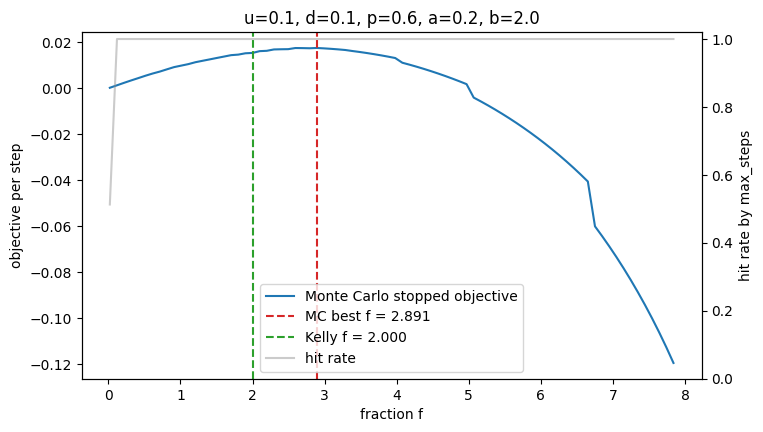

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(results_df["f"], results_df["growth_rate"], label="Monte Carlo stopped objective")
ax.axvline(best["f"], color="tab:red", linestyle="--", label=f"MC best f = {best['f']:.3f}")

one_step_mask = results_df["f"] >= one_step_min_f
if one_step_mask.any():
    ax.plot(
        results_df.loc[one_step_mask, "f"],
        results_df.loc[one_step_mask, "one_step_growth"],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        label="exact one-step objective",
    )

if f_min <= classic_kelly <= f_max:
    ax.axvline(classic_kelly, color="tab:green", linestyle="--", label=f"Kelly f = {classic_kelly:.3f}")
if f_min <= one_step_min_f <= f_max:
    ax.axvline(one_step_min_f, color="0.35", linestyle="-.", label=f"N=1 starts at f = {one_step_min_f:.3f}")

ax.set_xlabel("fraction f")
ax.set_ylabel("objective per step")
ax.set_title(f"u={u}, d={d}, p={p}, a={a}, b={b}")

ax_hit = ax.twinx()
ax_hit.plot(results_df["f"], results_df["hit_rate"], color="0.55", alpha=0.45, label="hit rate")
ax_hit.set_ylabel("hit rate by max_steps")
ax_hit.set_ylim(0, 1.02)

lines, labels = ax.get_legend_handles_labels()
hit_lines, hit_labels = ax_hit.get_legend_handles_labels()
ax.legend(lines + hit_lines, labels + hit_labels, loc="best")
plt.show()

In [19]:
def sweep_parameter(
    name,
    values,
    base_params,
    f_values,
    *,
    n_paths=2_000,
    max_steps=3_000,
    batch_size=1_000,
    seed=10_000,
):
    rows = []
    base_f_values = torch.as_tensor(f_values, dtype=torch.get_default_dtype()).reshape(-1)

    for i, value in enumerate(values):
        params = dict(base_params)
        params[name] = float(value)

        local_f_max = 0.98 * (1.0 - params["a"]) / params["d"]
        local_f_values = base_f_values[base_f_values < local_f_max]
        if local_f_values.numel() == 0:
            continue

        sweep_results = estimate_stopped_growth(
            **params,
            f_values=local_f_values,
            n_paths=n_paths,
            max_steps=max_steps,
            batch_size=batch_size,
            seed=seed + i,
        )
        frame = results_frame(sweep_results)
        best_row = frame.loc[frame["growth_rate"].idxmax()]
        rows.append(
            {
                name: float(value),
                "best_f": best_row["f"],
                "best_growth_rate": best_row["growth_rate"],
                "best_mean_N": best_row["mean_N"],
                "best_hit_rate": best_row["hit_rate"],
                "min_hit_rate": frame["hit_rate"].min(),
            }
        )

    return pd.DataFrame(rows)


base_params = {"u": u, "d": d, "p": p, "a": a, "b": b}

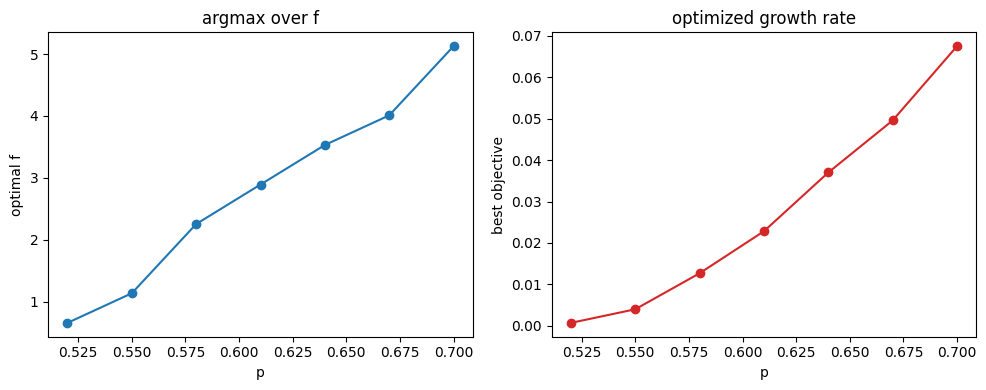

,p,best_f,best_growth_rate,best_mean_N,best_hit_rate,min_hit_rate
0,0.52,0.658367,0.000744,157.9375,1.0,0.0000
1,0.55,1.137143,0.004025,46.3460,1.0,0.0000
2,0.58,2.254286,0.012705,12.2540,1.0,0.0000
3,0.61,2.892653,0.022835,8.9900,1.0,0.0000
4,0.64,3.531020,0.036992,7.3600,1.0,0.0010
5,0.67,4.009796,0.049538,6.1280,1.0,0.6615
6,0.70,5.126939,0.067440,4.8710,1.0,1.0000


In [20]:
# Change "p" to "u", "d", "a", or "b" and change the values to sweep a different parameter.
sweep_name = "p"
sweep_values = torch.linspace(0.52, 0.70, 7)
sweep_f_grid = torch.linspace(f_min, f_max, 50)

sweep_df = sweep_parameter(
    sweep_name,
    sweep_values,
    base_params,
    sweep_f_grid,
    n_paths=2_000,
    max_steps=3_000,
    batch_size=batch_size,
    seed=10_000,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(sweep_df[sweep_name], sweep_df["best_f"], marker="o")
axes[0].set_xlabel(sweep_name)
axes[0].set_ylabel("optimal f")
axes[0].set_title("argmax over f")

axes[1].plot(sweep_df[sweep_name], sweep_df["best_growth_rate"], marker="o", color="tab:red")
axes[1].set_xlabel(sweep_name)
axes[1].set_ylabel("best objective")
axes[1].set_title("optimized growth rate")

plt.tight_layout()
plt.show()
sweep_df